## Modeling behavior by State Space Model

In [1]:
%reload_ext autoreload
%autoreload 2

In [177]:
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from scipy.special import comb
from dynamax.hidden_markov_model import CategoricalHMM
from spyglass.shijiegu.changeOfMind_statespace import (cycle4_1, cycle4_2, cycle4_3, cycle4_4, cycle4_5, cycle4_6,
                                                       cycle3_1, cycle3_2, cycle3_3, cycle3_4, cycle3_5, cycle3_6, cycle3_7, cycle3_8, cycle_lengths)
from spyglass.shijiegu.changeOfMind_statespace import (construct_transition_matrix, construct_emission_matrix,
                                                      initialize_state_space, em_state_space, get_day_observations,
                                                      return_cycle_type_posterior, return_target_seq_posterior,
                                                      return_A_seq_level)

from jax import vmap
from functools import partial

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta
import optax

In [479]:
animal = "eliot"
day = "20221022"
correct_seq_name = "seq2"

# animal = "lewis"
# day = "20240109"
# correct_seq_name = "rev2"

# animal = "julio"
# day = "20230810"
# correct_seq_name = "seq2"

# animal = "molly"
# day = "20220418"
# correct_seq_name = "seq2"

if correct_seq_name == "rev2":
    correct_seq = cycle4_5
else:
    correct_seq = cycle4_2

emission_all, df_all = get_day_observations(animal, day)

init_num = 10

em_log = 0
em_params = None
input_params = None
for num in range(init_num):

    seed = num
    # A = construct_transition_matrix(seed, p_stay_in_seq = 0.5, # proportional to 4a
    #                              p_jump_to_other_seq = 0.2, # proportional to 4B * 5
    #                              p_jump_to_other_seq_type = 0.1, # proportional to 3b * 8
    #                              p_jump_to_random = 0.5)
    # E = construct_emission_matrix(noise_level = 0.6)
    A = construct_transition_matrix(seed, p_stay_in_seq = 0.8, # proportional to 4a
                                  p_jump_to_other_seq = 0.2, # proportional to 4B * 5
                                  p_jump_to_other_seq_type = 0.1, # proportional to 3b * 8
                                  p_jump_to_random = 0.5)
    E = construct_emission_matrix(noise_level = 1)
 
    hmm, init_params, props = initialize_state_space(A, E)
    #props.emissions.probs.trainable = False
    em_params_k, em_log_k = em_state_space(hmm, init_params, props, emission_all)
    print("em log ", em_log_k[-1])
    if em_log_k[-1] > em_log:
        print("found a better solution")
        em_params = em_params_k
        em_log = em_log_k[-1]
        input_params = init_params


eliot20221022_.nwb


em log  6838.574
found a better solution


em log  6836.9473


em log  6838.586
found a better solution


em log  6838.58


...

em log  6838.2656


em log  6838.579


em log  6838.2666


em log  6838.5815


em log  6838.4814


In [480]:
### inspect changes in the sequence-level transition matrix

Text(0.5, 1.0, 'Estimated transitions')

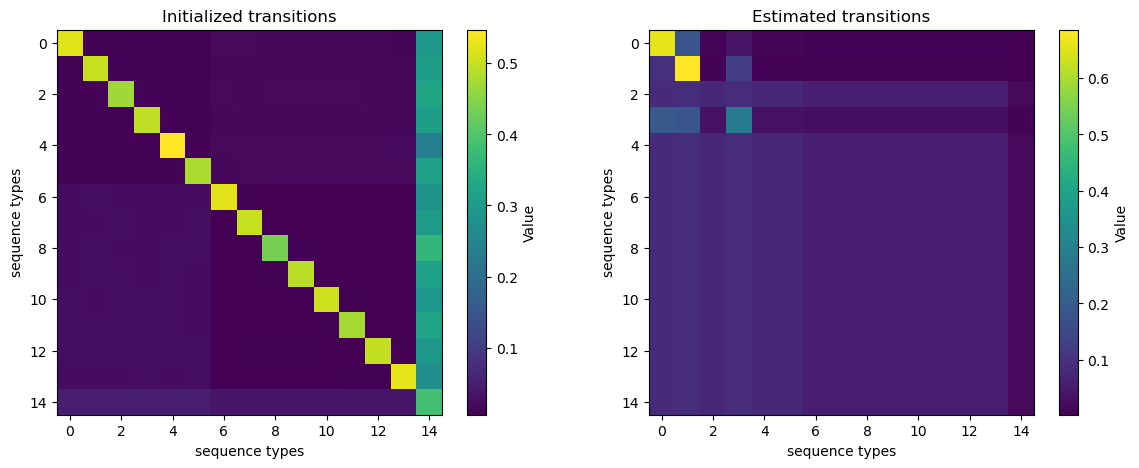

In [481]:
fig,axes=plt.subplots(1,2,sharex=True,figsize=(14,5))

ax = axes[0]
A_pre = input_params[1].transition_matrix
A_seq_pre = return_A_seq_level(A_pre)
im = ax.imshow(A_seq_pre)
plt.colorbar(im, ax=axes[0], label='Value')
ax.set_xlabel("sequence types")
ax.set_ylabel("sequence types")
ax.set_title("Initialized transitions")

ax = axes[1]
A_post = em_params[1].transition_matrix
A_seq_post = return_A_seq_level(A_post)
im = ax.imshow(A_seq_post)
plt.colorbar(im, ax=axes[1], label='Value')
ax.set_xlabel("sequence types")
ax.set_ylabel("sequence types")
ax.set_title("Estimated transitions")

In [494]:
# input
session_ind = 3
df = df_all[session_ind]   

min_num = 0
max_num = 80
t0 = df.loc[min_num:max_num].timestamp_H
t1 = df.loc[min_num:max_num].timestamp_O
outers = df.loc[min_num:max_num].OuterWellIndex #outer arm choice
rewarded = df.loc[min_num:max_num].rewardNum == 2
com = df.loc[min_num:max_num].change_of_mind
illegal = df.loc[min_num:max_num].rewardNum == 0
remote_theta = df.loc[min_num:max_num].has_remote_interval == 1

# get 3-cycle vs 4-cycle state
all_outers = np.array(df.OuterWellIndex)-1
assert (all_outers == np.nan).any() == False

all_outers = jnp.array(all_outers[min_num:max_num])
cycle3_posterior, cycle4_posterior, random_posterior = return_cycle_type_posterior(hmm, em_params, all_outers)
target_posterior, confound1_posterior, confound2_posterior = return_target_seq_posterior(hmm, em_params, all_outers, correct_seq_name)

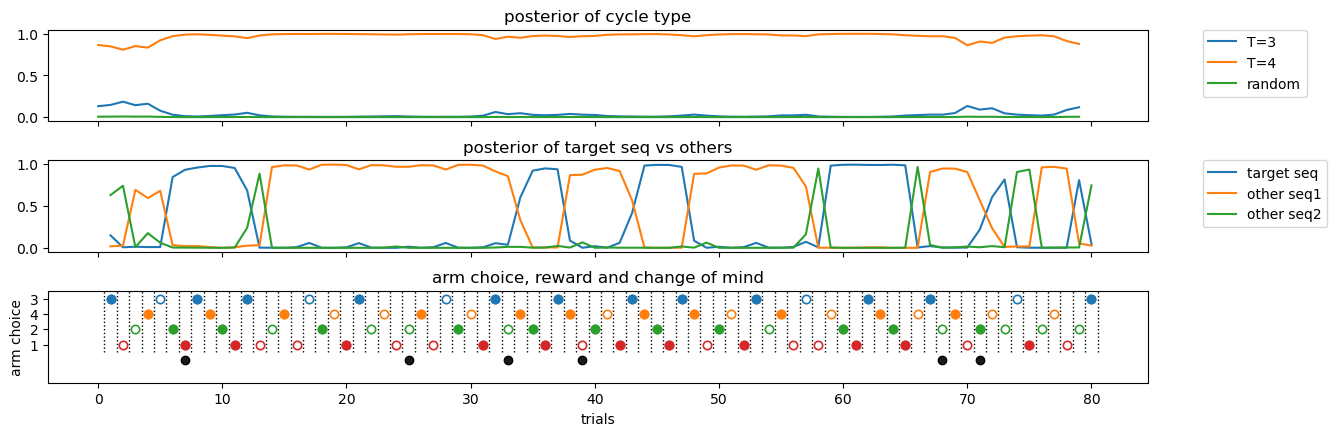

In [495]:
# arange_type
seqn = correct_seq

fig,axes=plt.subplots(3,1,sharex=True,figsize=(14,5))

ax0 = axes[0]
ax0.plot(cycle3_posterior, label = "T=3")
ax0.plot(cycle4_posterior, label = "T=4")
ax0.plot(random_posterior, label = "random")
ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax0.set_title("posterior of cycle type")

ax1 = axes[1]
ax1.plot(np.arange(len(target_posterior)) + 1, target_posterior, label = "target seq")
ax1.plot(np.arange(len(target_posterior)) + 1,confound1_posterior, label = "other seq1")
ax1.plot(np.arange(len(target_posterior)) + 1,confound2_posterior, label = "other seq2")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax1.set_title("posterior of target seq vs others")

ax = axes[2]
ax.set_title("arm choice, reward and change of mind")
for t in range(len(outers)+1):
    ax.plot([t+0.5,t+0.5],[-0.5,3.5],'k:',linewidth=1,)
        
    # choices, rewards etc
for a in range(4): # arm 1-4
    a_trials=np.argwhere(outers==seqn[a]).ravel() + 1
    ax.scatter(a_trials,3-a*np.ones_like(a_trials),linewidths=1.2,edgecolors='C'+str(a),facecolor=[1,1,1])
            
    rewarded_a=np.argwhere(np.logical_and(outers==seqn[a],rewarded)).ravel() + 1;
    ax.scatter(rewarded_a,3-a*np.ones_like(rewarded_a),edgecolors='C'+str(a),facecolor='C'+str(a),);
            
    #illegal_a=np.argwhere(np.logical_and(outers==seqn[a],illegal)).ravel();
    #ax.scatter(illegal_a,3-a*np.ones_like(illegal_a),edgecolors='C'+str(a),facecolor=[0.1,0.1,0.1]);

    com_a=np.argwhere(np.logical_and(outers==seqn[a],com)).ravel() + 1;
    ax.scatter(com_a,np.ones_like(com_a)-2,edgecolors='k',facecolor=[0.1,0.1,0.1]);

    rtheta_a=np.argwhere(np.logical_and(outers==seqn[a],remote_theta)).ravel() + 1;
    ax.scatter(rtheta_a,np.ones_like(rtheta_a)-2.2,edgecolors='magenta',marker='^',facecolor=[0.1,0.1,0.1]);

    
            
            
ax.set_yticks(np.arange(4))
ax.set_yticklabels(seqn[::-1])
ax.set_ylabel('arm choice')
ax.set_xlabel('trials')
ax.set_ylim([-2.5,3.5])
#axes.set_title(data['date_session'][s]+' '+data['seq'][s],loc='left')
        
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

### End here

In [484]:
### draft for triggering code

In [485]:
# change of mind trials
def return_triggered_matrix(trialIDs, target_posterior, t_minus = 4, t_plus = 4):
    # trialID is index-ed!!!
    # trials in rows
    # 
    triggers = np.zeros((len(trialIDs), t_minus + t_plus + 1)) + np.nan
    for row_ind in range(len(trialIDs)):
        trialID = trialIDs[row_ind]
        trial_index = trialID - 1
    
        index = np.arange(np.max([trial_index - t_minus, 0]), np.min([trial_index + t_plus + 1, max_num]))
        triggers[row_ind, index - trial_index + t_minus] = target_posterior[index]

    return triggers


In [486]:
subset_df = df.loc[min_num:max_num]
subset_df_com = subset_df[subset_df.change_of_mind]
subset_df_notcom = subset_df[~subset_df.change_of_mind]

com_trialID = np.array(subset_df_com.index)
notcom_trialID = np.array(subset_df_notcom.index)

t_minus = 4
t_plus = 4
com_triggers = return_triggered_matrix(com_trialID, target_posterior, t_minus = t_minus, t_plus = t_plus)
notcom_triggers = return_triggered_matrix(notcom_trialID, target_posterior, t_minus = t_minus, t_plus = t_plus)

In [487]:
com_triggers.shape

(5, 9)

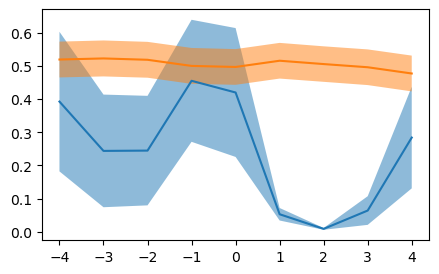

In [488]:
fig, axes = plt.subplots(1, 1, figsize=(5, 3))

data1 = com_triggers

mean = np.nanmean(data1, axis = 0)
sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])

x = np.arange(len(mean))- t_minus
axes.plot(x, mean)
axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)

data1 = notcom_triggers
mean = np.nanmean(data1, axis = 0)
sd_err = np.nanstd(data1, axis = 0)/np.sqrt(np.shape(data1)[0])

x = np.arange(len(mean))- t_minus
axes.plot(x, mean)
axes.fill_between(x, mean - sd_err, mean + sd_err, alpha = 0.5)


In [489]:
df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,has_remote_interval,remote_interval,remote_content,change_of_mind_num,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
1,1.666472e+09,1.0,1.666472e+09,3.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,3.0,3.0,4.0,NaN,NaN
2,1.666472e+09,1.0,1.666472e+09,4.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,4.0,4.0,2.0,3.0,3.0
3,1.666472e+09,1.0,1.666472e+09,2.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,2.0,2.0,1.0,4.0,4.0
4,1.666472e+09,1.0,1.666472e+09,1.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,1.0,1.0,3.0,2.0,2.0
5,1.666472e+09,1.0,1.666472e+09,3.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,3.0,3.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.666474e+09,1.0,1.666474e+09,2.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,2.0,2.0,1.0,3.0,3.0
79,1.666474e+09,1.0,1.666474e+09,1.0,1.0,True,False,[],[],[],...,0.0,0.0,0.106984,1,1,1.0,1.0,1.0,2.0,3.0
80,1.666474e+09,1.0,1.666474e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,1.0,1.0,4.0,1.0,3.0
81,1.666474e+09,1.0,1.666474e+09,4.0,2.0,False,False,[],[],[],...,NaN,NaN,NaN,0,0,4.0,4.0,NaN,1.0,3.0


In [313]:
index - trial_index + t_minus

array([0, 1, 2, 3, 4, 5])

In [349]:
mean

array([0.58290717, 0.60349252, 0.58905415, 0.57853305, 0.54726659,
       0.53608029, 0.54213944, 0.53661195,        nan])

In [316]:
trial_index + t_plus

84

In [298]:



com_indices = com_trialID - 1
notcom_indices = notcom_trialID - 1

current_com = target_posterior[com_indices]
current_notcom = target_posterior[notcom_indices]

delta_next_com = target_posterior[com_indices + 1] - target_posterior[com_indices]
delta_next_notcom = target_posterior[notcom_indices + 1] - target_posterior[notcom_indices]

delta_prev_com = target_posterior[com_indices] - target_posterior[com_indices - 1]
delta_prev_notcom = target_posterior[notcom_indices] - target_posterior[notcom_indices - 1]

(array([0.04477612, 0.05970149, 0.02985075, 0.        , 0.        ,
        0.        , 0.01492538, 0.        , 0.07462688, 0.59701443,
        0.08955216, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01492536, 0.01492536, 0.05970144]),
 array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
        -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
         0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
         0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ]),
 <BarContainer object of 19 artists>)

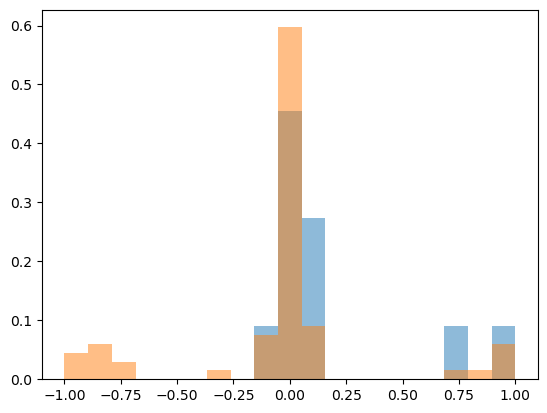

In [303]:
data1 = delta_prev_com
data2 = delta_prev_notcom

plt.hist(data1, weights = np.ones_like(data1)/len(data1), bins = np.linspace(-1,1,20), alpha = 0.5)
plt.hist(data2, weights = np.ones_like(data2)/len(data2), bins = np.linspace(-1,1,20), alpha = 0.5)

In [295]:
notcom_trialID

array([48, 12, 63, 23, 53, 37, 42,  1, 68, 33, 17])

In [276]:
len(target_posterior)

80

In [275]:
subset_df_com.index

Index([20, 21, 31, 38, 43, 55, 62, 70, 71, 77, 80], dtype='int64')